# Classifiers — Exercise 5: Logistic Regression on the Titanic Dataset

**Course:** Introduction to Machine Learning and Applied Artificial Intelligence
**Institution:** High School of Digital Culture, ITMO University


<a href="https://colab.research.google.com/github/Mir-robotics/ITMO-Introduction-to-Machine-Learning-and-Applied-Artificial-Intelligence/blob/main/Logistic%20Regression/Logistic_Regression_Exercise_5.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


This notebook builds a **logistic regression** classifier to predict Titanic passenger
survival, and — like the earlier fish-weight regression exercise — the real lesson is
about **data cleaning and feature engineering**, not the model itself. We compare
several strategies for handling missing values and categorical features, and measure
how much each one actually helps.

Throughout, we use scikit-learn's logistic regression with fixed settings:

```python
from sklearn.linear_model import LogisticRegression
LogisticRegression(random_state=2019, solver='lbfgs').fit(X, y)
```

(See the [LogisticRegression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
for details. Individual steps below use `random_state=35, max_iter=1000` to match the
exercise's grading parameters.)


## Dataset description

The [dataset](https://drive.google.com/file/d/1qTELQc2Nvl8gx_PRWhuuo22eskHL2za2/view?usp=sharing)
contains information about the passengers of the Titanic, which sank on the night of
April 15, 1912. Passenger survival depended on many factors, including gender, age,
which deck their cabin was on, and social status.

| Column | Description |
|---|---|
| `survived` (target) | Whether the passenger survived (0 = No, 1 = Yes) |
| `pclass` | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| `sex` | Gender (`female` or `male`) |
| `age` | Age in years |
| `sibsp` | Number of siblings/spouses aboard |
| `parch` | Number of parents/children aboard |
| `ticket` | Ticket number |
| `fare` | Passenger fare |
| `cabin` | Cabin number |
| `embarked` | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

The goal is to predict `survived` from the other features.


## 0. Setup and data loading

> **Note on data access:** the original exercise ran on Google Colab and loaded the
> file from the author's personal Google Drive. This version instead expects the CSV
> locally at `data/titanic_train.csv` — download it from the
> [link above](https://drive.google.com/file/d/1qTELQc2Nvl8gx_PRWhuuo22eskHL2za2/view?usp=sharing)
> and place it in a `data/` folder next to this notebook (or update `DATA_PATH`
> below).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
%matplotlib inline


In [3]:
DATA_PATH = "data/titanic_train.csv"

data = pd.read_csv(DATA_PATH, encoding="utf-8", delimiter=",")
data.head()


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest
0,3,1,"Smyth, Miss. Julia",female,NaN,0,0,335432,7.7333,NaN,Q,NaN
1,3,1,"Glynn, Miss. Mary Agatha",female,NaN,0,0,335677,7.7500,NaN,Q,"Co Clare, Ireland Washington, DC"
2,3,1,"Whabee, Mrs. George Joseph (Shawneene Abi-Saab)",female,38.0,0,0,2688,7.2292,NaN,C,NaN
3,3,0,"Vovk, Mr. Janko",male,22.0,0,0,349252,7.8958,NaN,S,NaN
4,3,0,"de Pelsmaeker, Mr. Alfons",male,16.0,0,0,345778,9.5000,NaN,S,NaN


## 1. Exploratory analysis


In [4]:
missing_age = data["age"].isnull().sum()
print(f"Missing values in 'age': {missing_age}")


Missing values in 'age': 199


In [5]:
survival_rate = round(data[data["survived"] == 1].shape[0] / data.shape[0], 3)
print(f"Proportion of survivors: {survival_rate}")


Proportion of survivors: 0.382


### Dropping high-missingness / low-value columns

We check the proportion of missing values in each column and drop any feature that's
missing more than a third of its values, on the logic that such a feature is too
sparse to reliably impute or use. We also drop `ticket`, since a raw ticket number is
unlikely to carry useful predictive signal on its own.


In [6]:
missing_fraction = data.isnull().mean()
high_missing_cols = missing_fraction[missing_fraction > 1 / 3].index.tolist()

print(f"Columns with >1/3 missing values: {high_missing_cols}")
print(missing_fraction.round(3))


Columns with >1/3 missing values: ['cabin', 'home.dest']
pclass       0.000
survived     0.000
name         0.000
sex          0.000
age          0.203
sibsp        0.000
parch        0.000
ticket       0.000
fare         0.000
cabin        0.784
embarked     0.000
home.dest    0.422
dtype: float64


In [7]:
data.drop(columns=high_missing_cols + ["ticket"], inplace=True)
data.isnull().sum()


,0
pclass,0
survived,0
name,0
sex,0
age,199
sibsp,0
parch,0
fare,0
embarked,0


### Combining `sibsp` and `parch` into a single family-size feature

Both `sibsp` (siblings/spouses aboard) and `parch` (parents/children aboard)
essentially describe family size, so we combine them into a single `fam_size`
feature.


In [8]:
data["fam_size"] = data["sibsp"] + data["parch"]
data.drop(columns=["sibsp", "parch"], inplace=True)

print(f"Sample mean of fam_size: {round(data['fam_size'].mean(), 3)}")
data.head()


Sample mean of fam_size: 0.866


,pclass,survived,name,sex,age,fare,embarked,fam_size
0,3,1,"Smyth, Miss. Julia",female,NaN,7.7333,Q,0
1,3,1,"Glynn, Miss. Mary Agatha",female,NaN,7.7500,Q,0
2,3,1,"Whabee, Mrs. George Joseph (Shawneene Abi-Saab)",female,38.0,7.2292,C,0
3,3,0,"Vovk, Mr. Janko",male,22.0,7.8958,S,0
4,3,0,"de Pelsmaeker, Mr. Alfons",male,16.0,9.5000,S,0


This cleaned dataset — with high-missingness columns and `ticket` dropped, and
`fam_size` engineered — is our starting point for everything that follows. We call it
`initial`; nothing dropped at this stage needs to come back later.


In [9]:
initial = data.copy(deep=True)

n_predictors = initial.shape[1] - 1  # exclude the target column 'survived'
print(f"Number of predictors in the initial dataset: {n_predictors}")


Number of predictors in the initial dataset: 7


### A quick sanity check: survival by subgroup

Before modeling, it's informative to check the raw (empirical) survival rate within a
specific subgroup — here, first-class female passengers — as a baseline intuition for
how strong the `sex`/`pclass` signal is likely to be.


In [10]:
subgroup = initial[(initial["sex"] == "female") & (initial["pclass"] == 1)]
subgroup_survival_rate = round(
    subgroup[subgroup["survived"] == 1].shape[0] / subgroup.shape[0], 3
)
print(f"Survival rate, female & 1st class: {subgroup_survival_rate}")


Survival rate, female & 1st class: 0.971


That's a striking number — first-class women survived at a very high rate, which
matches the historical "women and children first" evacuation policy plus the
advantage of first-class cabins being closer to the lifeboat deck.

### Visualizing survival by age


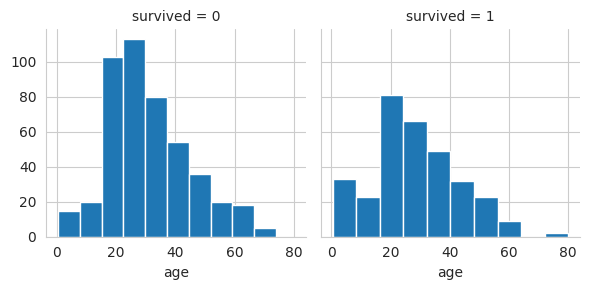

In [11]:
g = sns.FacetGrid(initial, col="survived")
g.map(plt.hist, "age", bins=10)
plt.show()


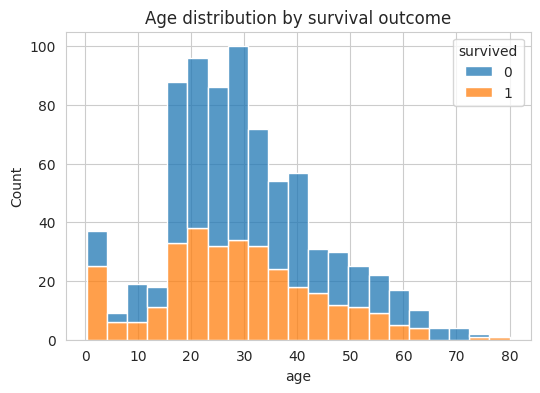

In [12]:
plt.figure(figsize=(6, 4))
sns.histplot(data=initial, x="age", hue="survived", multiple="stack")
plt.title("Age distribution by survival outcome")
plt.show()


## 2. Model based on numerical features only

We'll compare three strategies for handling the missing `age` values, all using the
same numeric feature set (`pclass`, `age`, `fare`, `fam_size`) and the same
train/test split and model settings, so the *only* thing that changes between them is
how `age` is filled in.


### 2a. Baseline: drop rows with missing values

The simplest possible approach — just discard any row with a missing value.


In [13]:
base = initial.drop(columns=["name", "sex", "embarked"]).dropna()
base.head()


,pclass,survived,age,fare,fam_size
2,3,1,38.0,7.2292,0
3,3,0,22.0,7.8958,0
4,3,0,16.0,9.5000,0
5,3,1,29.0,7.7500,0
7,1,0,25.0,26.0000,0


In [14]:
X = base[["pclass", "age", "fare", "fam_size"]]
y = base["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=35, stratify=y
)

log_reg_base = LogisticRegression(random_state=35, max_iter=1000).fit(X_train, y_train)
y_pred_base = log_reg_base.predict(X_test)

print(f"F1 score (dropped missing rows): {round(f1_score(y_test, y_pred_base), 3)}")


F1 score (dropped missing rows): 0.518


### 2b. Fill missing `age` with the column mean

Rather than losing rows, we impute the missing ages with the overall mean age.


In [15]:
data_mean_fill = initial.drop(columns=["name", "sex", "embarked"]).copy()
data_mean_fill["age"] = data_mean_fill["age"].fillna(data_mean_fill["age"].mean())

X1 = data_mean_fill[["pclass", "age", "fare", "fam_size"]]
y1 = data_mean_fill["survived"]

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, test_size=0.2, random_state=35, stratify=y1
)

log_reg_mean = LogisticRegression(random_state=35, max_iter=1000).fit(X_train1, y_train1)
y_pred_mean = log_reg_mean.predict(X_test1)

print(f"F1 score (mean-filled age): {round(f1_score(y_test1, y_pred_mean), 3)}")


F1 score (mean-filled age): 0.483


### 2c. Fill missing `age` based on the passenger's honorific

Filling every missing age with the same overall mean ignores useful context: the
`name` column contains a title (`Mr.`, `Mrs.`, `Miss.`, `Master.`, etc.) that strongly
correlates with age and sex. We extract the honorific and use the *group* mean age
instead of the *global* mean.


In [16]:
data_honorific = initial.drop(columns=["sex", "embarked"]).copy()

data_honorific["honorific"] = data_honorific["name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
data_honorific.drop(columns=["name"], inplace=True)

print(f"Distinct honorifics ({data_honorific['honorific'].nunique()}):")
print(sorted(data_honorific["honorific"].unique()))


Distinct honorifics (14):
['Capt', 'Col', 'Countess', 'Don', 'Dona', 'Dr', 'Major', 'Master', 'Miss', 'Mlle', 'Mr', 'Mrs', 'Ms', 'Rev']


Many of these honorifics are rare variants of the same social role, so we fold the
small groups into the larger, more common ones. `Master` (the historical form of
address for a boy) is kept separate, since it should correlate strongly with a young
age — unlike `Mr`.


In [17]:
data_honorific["honorific"] = data_honorific["honorific"].replace(
    ["Rev", "Col", "Dr", "Major", "Don", "Capt"], "Mr"
)
data_honorific["honorific"] = data_honorific["honorific"].replace(["Dona", "Countess"], "Mrs")
data_honorific["honorific"] = data_honorific["honorific"].replace(["Mlle", "Ms"], "Miss")

print(f"Distinct honorifics after grouping ({data_honorific['honorific'].nunique()}):")
print(sorted(data_honorific["honorific"].unique()))


Distinct honorifics after grouping (4):
['Master', 'Miss', 'Mr', 'Mrs']


In [18]:
master_fraction = round(
    data_honorific[data_honorific["honorific"] == "Master"].shape[0]
    / data_honorific[data_honorific["honorific"].isin(["Master", "Mr"])].shape[0],
    3,
)
print(f"Proportion of 'Master' among {{Master, Mr}}: {master_fraction}")

master_age_mean = data_honorific[data_honorific["honorific"] == "Master"]["age"].mean()
print(f"Average age of 'Master': {round(master_age_mean, 3)}")


Proportion of 'Master' among {Master, Mr}: 0.072
Average age of 'Master': 5.128


In [19]:
# Group-wise mean ages, used to fill missing values per honorific
group_age_means = data_honorific.groupby("honorific")["age"].mean()

for honorific in ["Miss", "Mrs", "Mr", "Master"]:
    mask = (data_honorific["honorific"] == honorific) & data_honorific["age"].isna()
    data_honorific.loc[mask, "age"] = group_age_means[honorific]

print(f"Remaining missing values:\n{data_honorific.isnull().sum()}")


Remaining missing values:
pclass       0
survived     0
age          0
fare         0
fam_size     0
honorific    0
dtype: int64


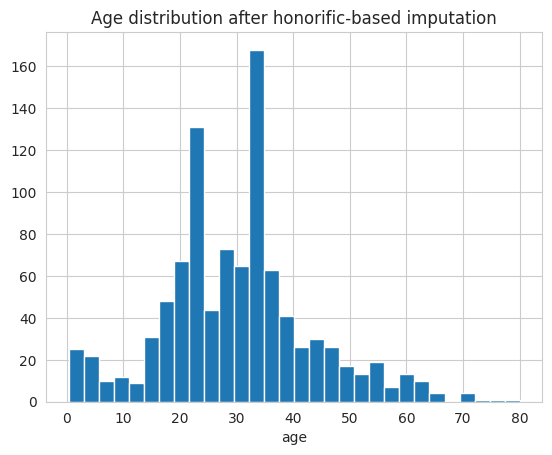

In [20]:
data_honorific["age"].hist(bins=30)
plt.title("Age distribution after honorific-based imputation")
plt.xlabel("age")
plt.show()


In [21]:
X2 = data_honorific[["pclass", "age", "fare", "fam_size"]]
y2 = data_honorific["survived"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=35, stratify=y2
)

log_reg_honorific = LogisticRegression(random_state=35, max_iter=1000).fit(X_train2, y_train2)
y_pred_honorific = log_reg_honorific.predict(X_test2)

print(f"F1 score (honorific-based age imputation): {round(f1_score(y_test2, y_pred_honorific), 3)}")


F1 score (honorific-based age imputation): 0.466


Interestingly, the more "intelligent" honorific-based imputation does **not** beat
the simpler baselines here (a good reminder that a more sophisticated-sounding method
doesn't automatically produce a better model — it needs to be checked empirically). All
three numeric-only strategies land in a similar, fairly modest F1 range. That's a
strong hint that the numeric features alone are missing something important — most
likely `sex`, which we've excluded so far.


## 3. Model using categorical features

Let's bring the categorical features (`sex`, `embarked`) back in. We reuse the
honorific-based age imputation from step 2c (our most principled imputation
strategy), then one-hot encode the categoricals with `drop_first=True` to avoid the
dummy-variable trap.


In [22]:
final = initial.copy(deep=True)

final["honorific"] = final["name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
final.drop(columns=["name"], inplace=True)

final["honorific"] = final["honorific"].replace(["Rev", "Col", "Dr", "Major", "Don", "Capt"], "Mr")
final["honorific"] = final["honorific"].replace(["Dona", "Countess"], "Mrs")
final["honorific"] = final["honorific"].replace(["Mlle", "Ms"], "Miss")

group_age_means_final = final.groupby("honorific")["age"].mean()
for honorific in ["Miss", "Mrs", "Mr", "Master"]:
    mask = (final["honorific"] == honorific) & final["age"].isna()
    final.loc[mask, "age"] = group_age_means_final[honorific]

final.drop(columns=["honorific"], inplace=True)

print(f"Remaining missing values:\n{final.isnull().sum()}")


Remaining missing values:
pclass      0
survived    0
sex         0
age         0
fare        0
embarked    0
fam_size    0
dtype: int64


In [23]:
final_encoded = pd.get_dummies(final, drop_first=True)
final_encoded.head()


,pclass,survived,age,fare,fam_size,sex_male,embarked_Q,embarked_S
0,3,1,22.005765,7.7333,0,False,True,False
1,3,1,22.005765,7.7500,0,False,True,False
2,3,1,38.000000,7.2292,0,False,False,False
3,3,0,22.000000,7.8958,0,True,False,True
4,3,0,16.000000,9.5000,0,True,False,True


In [24]:
feature_cols = ["pclass", "age", "fare", "fam_size", "sex_male", "embarked_Q", "embarked_S"]
X3 = final_encoded[feature_cols]
y3 = final_encoded["survived"]

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=35, stratify=y3
)

log_reg_final = LogisticRegression(random_state=35, max_iter=1000).fit(X_train3, y_train3)
y_pred_final = log_reg_final.predict(X_test3)

print(f"F1 score (with categorical features): {round(f1_score(y_test3, y_pred_final), 3)}")
print()
print(classification_report(y_test3, y_pred_final, digits=3))


F1 score (with categorical features): 0.71

              precision    recall  f1-score   support

           0      0.806     0.885     0.844       122
           1      0.778     0.653     0.710        75

    accuracy                          0.797       197
   macro avg      0.792     0.769     0.777       197
weighted avg      0.795     0.797     0.793       197



## Summary

| Strategy | F1 score |
|---|---|
| Numeric only, drop missing rows | ~0.52 |
| Numeric only, mean-filled age | ~0.48 |
| Numeric only, honorific-based age | ~0.47 |
| + categorical features (`sex`, `embarked`) | ~0.71 |

A few honest takeaways:

- **Refining the imputation strategy barely mattered.** Going from "drop missing
  rows" to "mean fill" to "honorific-based group-mean fill" did *not* improve, and
  even slightly hurt, F1 — despite the honorific-based approach being the most
  "sophisticated" of the three. With only ~20% of `age` values missing, the precise
  imputation method has limited room to move the needle either way.
- **Adding `sex` was the single biggest improvement by far**, jumping F1 from ~0.47
  to ~0.71. This matches the historical reality of "women and children first" — gender
  was one of the strongest real determinants of survival, so a model without it is
  missing the most informative feature available.
- The general lesson: when a linear model's performance is disappointing, it's worth
  asking "am I missing an informative *feature*?" before reaching for fancier
  preprocessing on the features you already have.
